|                |   |
:----------------|---|
| **Nombre**     | Valeria Guzmán Galván  |
| **Fecha**      | 08/05/2026  |
| **Expediente** | 756902  |

# **T10 - Particiones en árboles de clasificación**

Vimos en clase el concepto de minimizar la varianza conjunta para realizar particiones en árboles de regresión; dado que en clasificación las salidas son categorías, no se puede usar el mismo concepto.

**¿Por qué en árboles de clasificación NO se minimiza la varianza conjunta?**

En árboles de regresión, la variable respuesta es numérica. Entonces tiene sentido medir promedios, diferencias numéricas o varianza. Los árboles de regresión buscan minimizar RSS (Residual Sum of Squares), es decir, reducir la variabilidad dentro de cada nodo.

Pero en clasificación, la respuesta no es numérica sino categórica. Así que el árbol intenta medir qué tan mezcladas están las clases, qué tanta incertidumbre existe y qué tan puro es cada nodo.

## Investiga los siguientes conceptos y su conexión con las particiones en árboles de clasificación:

### **GINI**

Es una medida de impureza utilizada en árboles de clasificación. Su objetivo es medir qué tan mezcladas están las clases dentro de un nodo. Cuando la mayoría de las observaciones pertenecen a una sola clase, la impureza es pequeña; cuando las clases están distribuidas de manera similar, la impureza aumenta.

Para un nodo con *K* clases:

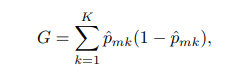

donde:
* *Pk* = Proporción de observaciones de la clase *k*

En los árboles de clasificación, el algoritmo evalúa distintas particiones y calcula el GINI de los nodos resultantes. La mejor partición será aquella que genere nodos más homogéneos y reduzca la impureza.

Un valor bajo de GINI indica que el nodo es puro y que existe una buena separación entre clases. El valor mínimo posible es G = 0, lo cual ocurre cuando todas las observaciones pertenecen a una sola clase.

Por otro lado, un valor alto de GINI indica que las clases están muy mezcladas. En clasificación binaria, el valor máximo ocurre cuando ambas clases tienen la misma proporción, es decir p = 0.5

El índice GINI es uno de los criterios más utilizados en árboles de clasificación porque es sencillo de calcular y computacionalmente eficiente. Además, penaliza los nodos donde existe mayor mezcla entre clases, favoreciendo particiones más puras.

### **Entropía**

La entropía es una medida de impureza utilizada en árboles de clasificación. Su función es medir el nivel de desorden o incertidumbre dentro de un nodo. Cuando las observaciones pertenecen principalmente a una sola clase, la entropía es pequeña; cuando las clases están mezcladas de manera similar, la incertidumbre aumenta.

Fórmula:

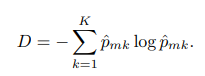

donde:
* *Pk* = Proporción de observaciones de la clase *k*

En los árboles de clasificación, el algoritmo calcula la entropía de las posibles particiones y selecciona aquella que reduzca más la incertidumbre, generando nodos más homogéneos.

El valor mínimo ocurre cuando todas las observaciones pertenecen a una sola clase. En clasificación binaria, la entropía alcanza su valor máximo cuando ambas clases tienen la misma proporción.

La entropía es muy similar al índice GINI y generalmente ambos criterios producen árboles parecidos. Sin embargo, la entropía penaliza un poco más los nodos donde las clases están muy mezcladas.

### **Log Loss**

Es una medida utilizada para evaluar qué tan precisas son las probabilidades predichas por un modelo de clasificación. Su objetivo es penalizar las predicciones incorrectas, especialmente cuando el modelo se equivoca con mucha confianza.

Fórmula general:

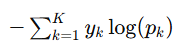

donde:
* yk = valor real de la clase
* pk = probabilidad predicha para la clase k

En clasificación binaria también puede expresarse como:

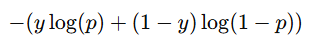

Log Loss castiga mucho las predicciones incorrectas hechas con demasiada confianza. Por ejemplo, equivocarse al predecir una probabilidad de 0.99 genera una penalización mucho mayor que equivocarse con una probabilidad de 0.55. Por esta razón, el modelo no solo busca clasificar correctamente, sino también asignar probabilidades razonables.

En árboles de clasificación, el algoritmo evalúa distintas particiones y selecciona aquella que reduzca más la pérdida, favoreciendo nodos con menor incertidumbre.

Un valor pequeño de Log Loss indica probabilidades más precisas, mientras que un valor grande representa mayor error e incertidumbre en las predicciones.

### **¿Cuál es la diferencia entre entropía y log loss?**

*Entropía:*
* Mide el desorden de un nodo
* Se usa para decidir particiones
* Depende de las proporciones de clases

*Log Loss:*
* Mide qué tan precisas son las probabilidades predichas
* Evalúa el error probabilístico
* Castiga predicciones muy seguras y equivocadas

En árboles de clasificación, *Entropía* y *Log Loss* suelen producir resultados muy similares porque ambos trabajan con probabilidades y logaritmos.

## Escoge un dataset y realiza el ejemplo de hacer una partición para cada uno de los criterios de decisión.

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Default.csv to Default.csv


In [28]:
df = pd.read_csv("Default.csv")
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [30]:
# Variable objetivo
df["default"].value_counts()

,count
default,
No,9667
Yes,333


Se utilizó la variable balance para realizar una partición del dataset. La regla utilizada fue:

`balance < 1000`

In [31]:
left_node = df[df["balance"] < 1000]
right_node = df[df["balance"] >= 1000]

In [32]:
print("Nodo izquierdo:", len(left_node))
print("Nodo derecho:", len(right_node))

Nodo izquierdo: 6368
Nodo derecho: 3632


*Distribución de clases en cada nodo*

In [33]:
print("Nodo izquierdo")
print(left_node["default"].value_counts())

Nodo izquierdo
default
No     6362
Yes       6
Name: count, dtype: int64


El nodo izquierdo quedó compuesto casi completamente por observaciones de la clase “No”. Esto indica que el nodo es muy puro y presenta muy poca incertidumbre

In [34]:
print("Nodo derecho")
print(right_node["default"].value_counts())

Nodo derecho
default
No     3305
Yes     327
Name: count, dtype: int64


El nodo derecho contiene una mayor mezcla entre clases. Aunque sigue predominando la clase “No”, existe una proporción mayor de clientes con incumplimiento, por lo que la impureza aumenta.

### **GINI**

In [35]:
def gini(y):
    proportions = y.value_counts(normalize=True)
    gini_value = 1 - np.sum(proportions**2)
    return gini_value

In [36]:
gini_left = gini(left_node["default"])
gini_right = gini(right_node["default"])

print("GINI nodo izquierdo:", gini_left)
print("GINI nodo derecho:", gini_right)

GINI nodo izquierdo: 0.0018826465872072706
GINI nodo derecho: 0.16385418283878983


In [37]:
gini_total = (
    (len(left_node) / len(df)) * gini_left +
    (len(right_node) / len(df)) * gini_right
)

print("GINI total:", gini_total)

GINI total: 0.060710708553782064


El índice GINI del nodo izquierdo fue muy pequeño, lo que indica una separación casi perfecta entre clases. En cambio, el nodo derecho obtuvo un valor mayor debido a la mayor mezcla de observaciones.

El GINI total de la partición fue de 0.06071. Este resultado muestra que la variable `balance` logra generar nodos relativamente homogéneos y reduce considerablemente la impureza del dataset.




### **ENTROPÍA**

In [38]:
def entropy(y):
    proportions = y.value_counts(normalize=True)
    entropy_value = -np.sum(proportions * np.log2(proportions))
    return entropy_value

In [39]:
entropy_left = entropy(left_node["default"])
entropy_right = entropy(right_node["default"])

print("Entropía nodo izquierdo:", entropy_left)
print("Entropía nodo derecho:", entropy_right)

Entropía nodo izquierdo: 0.010829469804215569
Entropía nodo derecho: 0.43658008948708066


In [40]:
entropy_total = (
    (len(left_node) / len(df)) * entropy_left +
    (len(right_node) / len(df)) * entropy_right
)

print("Entropía total:", entropy_total)

Entropía total: 0.16546209487303218


La entropía del nodo izquierdo representa muy poca incertidumbre dentro del nodo. El nodo derecho presentó una entropía mayor porque contiene una mayor combinación de clases.

La entropía total obtenida fue de 0.16546. Esto indica que la partición disminuye el desorden y permite separar mejor las observaciones según la variable objetivo.

### **LOG LOSS**

In [41]:
def log_loss(y):
    proportions = y.value_counts(normalize=True)
    logloss_value = -np.sum(proportions * np.log(proportions))
    return logloss_value

In [42]:
logloss_left = log_loss(left_node["default"])
logloss_right = log_loss(right_node["default"])

print("Log Loss nodo izquierdo:", logloss_left)
print("Log Loss nodo derecho:", logloss_right)

Log Loss nodo izquierdo: 0.007506416461751085
Log Loss nodo derecho: 0.3026142581165786


In [43]:
logloss_total = (
    (len(left_node) / len(df)) * logloss_left +
    (len(right_node) / len(df)) * logloss_right
)

print("Log Loss total:", logloss_total)

Log Loss total: 0.11468958455078444


El Log Loss del nodo izquierdo fue muy pequeño, lo que indica probabilidades muy claras dentro del nodo. El nodo derecho presentó un valor mayor debido a la presencia de una mayor incertidumbre en las clases.

El Log Loss total fue de 0.11469. Este resultado muestra que la partición mejora la calidad de las probabilidades predichas y genera una clasificación más clara entre clientes con y sin incumplimiento.

### **COMPARACIÓN**

In [44]:
results = pd.DataFrame({
    "Criterio": ["GINI", "Entropía", "Log Loss"],
    "Resultado": [gini_total, entropy_total, logloss_total]
})

results

,Criterio,Resultado
0,GINI,0.060711
1,Entropía,0.165462
2,Log Loss,0.114690


Aunque GINI, Entropía y Log Loss utilizan fórmulas distintas, los tres criterios producen resultados similares porque todos buscan reducir la impureza y generar nodos más homogéneos. En este ejemplo, los tres métodos muestran que la variable `balance` ayuda a separar adecuadamente las clases del dataset.